In [2]:
!pip install tf-levenberg-marquardt

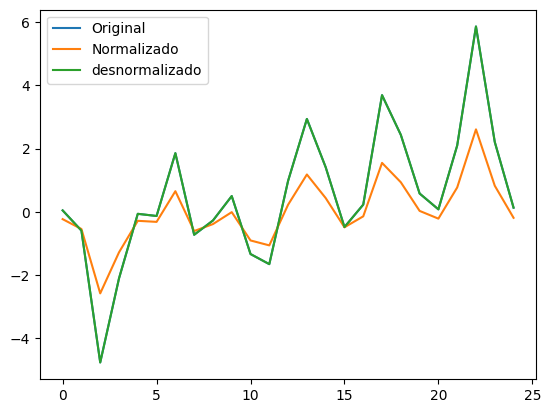

StandardScaler()

In [3]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

scaler = StandardScaler()
out_scaler = StandardScaler()
input_scaler = StandardScaler()

def peaks(grid):
    x = np.linspace(-2, 2, grid)
    y = np.linspace(-2, 2, grid)
    x, y = np.meshgrid(x, y)
    z = 3*(1-x)**2 * np.exp(-(x**2) - (y+1)**2) - 10*(x/5 - x**3 - y**5) * np.exp(-x**2 - y**2) - 1/3 * np.exp(-(x+1)**2 - y**2)
    return x, y, z

def create_dataframe(grid):
   x, y, z = peaks(grid)
   data = {'X': x.flatten(), 'Y': y.flatten(), 'Z': z.flatten()}
   df = pd.DataFrame(data)
   return df

def show_norm(df, label="Peaks", plot=False):
    df_norm = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)
    df_denorm = pd.DataFrame(scaler.inverse_transform(df_norm), columns=df_norm.columns)

    if (plot):
        df.plot(title=f"{label}: Original data")
        df_norm.plot(title=f"{label}: Normalized data")
        df_denorm.plot(title=f"{label}: Denormalized data")
    return (df_norm)

def test_out_scaler(df):
    out = df["Z"].values.reshape(-1, 1)  
    plt.plot(out, label='Original')
    out_scaler.fit(out)
    norm = out_scaler.transform(out)
    plt.plot(norm, label='Normalizado')
    denorm = out_scaler.inverse_transform(norm)
    plt.plot(denorm, label='desnormalizado')
    plt.legend()
    plt.show()

def split_df(df):
    _input = np.vstack([df['X'], df['Y']]).T
    _output = np.array(df['Z'])
    return (_input, _output)

df_25 = create_dataframe(grid=5)
df_25_norm = show_norm(df_25)
test_out_scaler(df_25)

df_1000 = create_dataframe(grid=32)
df_1000_norm = show_norm(df_1000)

_input, _output = split_df(df_25)
input_scaler.fit(_input)        

In [4]:
import tensorflow as tf
import numpy as np
from keras import regularizers
from keras import initializers
import tf_levenberg_marquardt as lm

# layers, neurons
class ShuffleArchitecture:
    def __init__(self, input_size, hidden_sizes, output_size, act_h, act_o, param_reg):
        self.input_size = input_size
        self.hidden_sizes = hidden_sizes
        self.output_size = output_size
        self.act_h = act_h
        self.act_o = act_o
        self.regularizer = regularizers.L2(param_reg)
        self.initializer = initializers.RandomUniform(minval=-0.5, maxval=0.5, seed=np.random.randint(1, 10000))

    def compute_k(self):
        total_parameters = 0
        for layer in self.model.layers:
            weights = layer.get_weights()
            if len(weights) > 0:  
                for w in weights:
                    total_parameters += np.prod(w.shape)
        return total_parameters
        
    def set_architecture(self):
        self.model = tf.keras.Sequential()
        self.model.add(tf.keras.layers.Dense(self.hidden_sizes[0],
                        input_shape=(self.input_size,),
                        activation=self.act_h,
                        kernel_regularizer=self.regularizer,
                        kernel_initializer=self.initializer,                        
                        ))  # input layer

        for size in self.hidden_sizes[1:]:  # hidden layers
            self.model.add(tf.keras.layers.Dense(size,
                            activation=self.act_h,
                            kernel_regularizer=self.regularizer,
                            kernel_initializer=self.initializer,  
                        ))

        self.model.add(tf.keras.layers.Dense(self.output_size,
                        activation=self.act_o,
                        kernel_regularizer=self.regularizer,
                        kernel_initializer=self.initializer,  
                        ))  # output layer

    def create_model(self, _learning_rate):
        mse_loss = lm.loss.MeanSquaredError()

        self.model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=_learning_rate),
            loss=mse_loss,
            metrics=['mse']
        )
        self.lm_model = lm.model.ModelWrapper(
            tf.keras.models.clone_model(self.model)
        )
        self.lm_model.compile(
            optimizer=tf.keras.optimizers.SGD(learning_rate=_learning_rate),
            loss=mse_loss
        )
        return self.lm_model

2025-05-21 13:16:40.308741: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [5]:
import pickle
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error, mean_absolute_percentage_error 
import plotly.figure_factory as ff
import plotly.offline as py
from scipy.spatial import Delaunay
import plotly.graph_objs as go
import os


class Rebuild:
    def __init__(self):
        self.df = pd.read_excel(f"better_results.xlsx")        
        self.sup_input, self.sup_output = split_df(df_1000_norm)

    def LoadModelWeights(self, model, fileName):        
        path = f"content/models/{fileName}.keras"
        model.load_weights(path)

    def LoadPrevDataset(self, fileName):
        fileName = fileName.replace("model", "dataset")
        pos = fileName.rfind("_")
        path = f"content/dataset/{fileName[:pos]}.pkl" 
        with open(path, 'rb') as f:
            _data, _train, _vt, _val, _test = pickle.load(f)
        self._data, self._train, self._vt, self._val, self._test = _data, _train, _vt, _val, _test    
    
    def setArchitecture(self, _hidden_sizes, _pg, _lr):
        shuffler = ShuffleArchitecture(input_size = 2,
                                    hidden_sizes = _hidden_sizes,
                                    output_size = 1,
                                    act_h = 'tanh',
                                    act_o = 'linear',
                                    param_reg = _pg)
        shuffler.set_architecture()
        return(shuffler.create_model(_lr))            

    def getArchitecture(self, architecture):
        hidden_size = [int(x) for x in architecture.split("[")[1].split("]")[0].split(", ")]
        regularizer = float(architecture.split("regularizer=")[1].split(",")[0])
        learning_rate = float(architecture.split("learning_rate=")[1])
        return hidden_size, regularizer, learning_rate

    def PlotResults(self, original_values, predicted_values):
        titles = ['Original vs. Preditos (Completo)',
                    'Original vs. Preditos (Teste)',
                    'Original vs. Preditos (Validação)',
                    'Original vs. Preditos (Validação e Teste)']
        fig, axes = plt.subplots(2, 2, figsize=(12, 8))
        for i, ax in enumerate(axes.flat):
            ax.plot(original_values[i], label='Original')
            ax.plot(predicted_values[i], label='Preditos')
            ax.set_title(titles[i])
            ax.legend()
        plt.tight_layout()
        plt.show()


    def predictResults(self, idx=-1):
        pred = self.lm_model.predict(self._data[0]).flatten()
        test_pred = self.lm_model.predict(self._test[0]).flatten()
        val_pred = self.lm_model.predict(self._val[0]).flatten()
        vt_pred = self.lm_model.predict(self._vt[0]).flatten()
        sup_pred = self.lm_model.predict(self.sup_input).flatten()

        # Calculando as metricas com a saida desnormalizada
        pred_denorm = out_scaler.inverse_transform(pred.reshape(-1, 1))
        test_pred_denorm = out_scaler.inverse_transform(test_pred.reshape(-1, 1))
        val_pred_denorm = out_scaler.inverse_transform(val_pred.reshape(-1, 1))
        vt_pred_denorm = out_scaler.inverse_transform(vt_pred.reshape(-1, 1))
        sup_pred_denorm = out_scaler.inverse_transform(sup_pred.reshape(-1, 1))

        out_denorm = out_scaler.inverse_transform(self._data[1].reshape(-1, 1))
        test_denorm = out_scaler.inverse_transform(self._test[1].reshape(-1, 1))
        val_denorm = out_scaler.inverse_transform(self._val[1].reshape(-1, 1))
        vt_denorm = out_scaler.inverse_transform(self._vt[1].reshape(-1, 1))
        sup_denorm = out_scaler.inverse_transform(self.sup_output.reshape(-1, 1))

        original_values = [out_denorm, test_denorm, val_denorm, vt_denorm, sup_denorm]
        predicted_values = [pred_denorm, test_pred_denorm, val_pred_denorm, vt_pred_denorm, sup_pred_denorm]

        if (idx != -1):
            self.RecalcMetrics(idx,
                                out_denorm, test_denorm, val_denorm, vt_denorm, sup_denorm,
                                pred_denorm, test_pred_denorm, val_pred_denorm, vt_pred_denorm, sup_pred_denorm)            
        return (original_values, predicted_values)

    def rebuildFullNet(self, model):
        for file_model, architecture in zip(self.df["model"], self.df["Architecture"]):
            if model == file_model:
                hidden_size, regularizer, learning_rate = self.getArchitecture(architecture)
                self.lm_model = self.setArchitecture(hidden_size, regularizer, learning_rate)
                self.LoadModelWeights(self.lm_model, file_model)
                self.LoadPrevDataset(file_model)
                original_values, predicted_values = self.predictResults()
                self.PlotResults(original_values, predicted_values)

    def create_dataset(self, input, output):
        input = tf.expand_dims(tf.cast(input, tf.float32), axis=-1)
        output = tf.expand_dims(tf.cast(output, tf.float32), axis=-1)
        dataset = tf.data.Dataset.from_tensor_slices((input, output))
        dataset = dataset.shuffle(len(input))
        dataset = dataset.batch(1000).cache()
        dataset = dataset.prefetch(tf.data.experimental.AUTOTUNE)
        return (dataset, input, output)

    def LoadNewDataset(self):
        x = np.linspace(-2, 2, 6)
        y = np.linspace(-2, 2, 6)
        x, y = np.meshgrid(x, y)
        z = 3*(1-x)**2 * np.exp(-(x**2) - (y+1)**2) - 10*(x/5 - x**3 - y**5) * np.exp(-x**2 - y**2) - 1/3 * np.exp(-(x+1)**2 - y**2)
        x = x.flatten()
        y = y.flatten()
        z = z.flatten()
        input = np.vstack([x,y]).T
        output = np.array(z)
        dataset = pd.DataFrame(input, columns=['x', 'y'])
        dataset['z'] = output
       # dataset, input, output = self.create_dataset(input, output)
        #dataset= pd.DataFrame(input,output)
        return (input, dataset)
    

    def mean_std(self, df):
        df_out = df.iloc[:, 2:]
        print(df)
        mean = df_out.mean(axis=1)
        std = df_out.std(axis=1)
        df["media"] = mean
        df["desvio padrao"] = std
        display(df)
        df.to_excel('results.xlsx', index=False)

    def TestNewData(self):
        input, df = self.LoadNewDataset()
        for file_model, architecture in zip(self.df["model"], self.df["Architecture"]):
            hidden_size, regularizer, learning_rate = self.getArchitecture(architecture)
            self.lm_model = self.setArchitecture(hidden_size, regularizer, learning_rate)
            self.LoadModelWeights(self.lm_model, file_model)
            pred = self.lm_model.predict(input).flatten()
            pred_denorm = out_scaler.inverse_transform(pred.reshape(-1, 1))
            df[file_model] = pred_denorm
        self.mean_std(df)
        df.to_excel
            
                


In [6]:
Rebuilder = Rebuild()
Rebuilder.TestNewData()

2/2 [==============================] - 0s 3ms/step
      x    y         z  model_20_8_2  model_20_8_3  model_20_8_1  \
0  -2.0 -2.0  0.046835     -1.167014     -1.156665     -1.178450   
1  -1.2 -2.0 -0.193496     -1.880771     -1.877286     -1.884634   
2  -0.4 -2.0 -3.152882     -4.934200     -4.935109     -4.933692   
3   0.4 -2.0 -4.659211     -6.170525     -6.166844     -6.174516   
4   1.2 -2.0 -1.313652     -1.379882     -1.380933     -1.378866   
5   2.0 -2.0 -0.061640     -0.170603     -0.159945     -0.182416   
6  -2.0 -1.2  0.008297     -0.720718     -0.720413     -0.721205   
7  -1.2 -1.2  0.997322      0.611118      0.608262      0.614250   
8  -0.4 -1.2 -0.232491     -1.184411     -1.189568     -1.178907   
9   0.4 -1.2 -4.183030     -3.122279     -3.120473     -3.124152   
10  1.2 -1.2 -0.534835     -0.098844     -0.103064     -0.094134   
11  2.0 -1.2  0.274603      0.591113      0.602445      0.578586   
12 -2.0 -0.4 -0.947252     -2.372404     -2.414052     -2.327490 

,x,y,z,model_20_8_2,model_20_8_3,model_20_8_1,model_20_8_0,model_4_8_4,model_34_6_8,model_34_6_7,...,model_34_6_16,model_34_6_17,model_34_6_3,model_34_6_18,model_34_6_19,model_34_6_20,model_34_6_21,model_34_6_2,media,desvio padrao
0,-2.0,-2.0,0.046835,-1.167014,-1.156665,-1.178450,-1.191081,-1.426001,-0.452923,-0.459538,...,-0.419886,-0.417527,-0.494059,-0.415431,-0.413569,-0.411913,-0.410437,-0.505149,-0.574384,0.341028
1,-1.2,-2.0,-0.193496,-1.880771,-1.877286,-1.884634,-1.888920,-2.424920,-1.729260,-1.716573,...,-1.803049,-1.809260,-1.655406,-1.814920,-1.820067,-1.824741,-1.828979,-1.636394,-1.740232,0.347243
2,-0.4,-2.0,-3.152882,-4.934200,-4.935109,-4.933692,-4.933762,-5.331015,-3.201430,-3.220191,...,-3.101782,-3.093930,-3.316780,-3.086814,-3.080370,-3.074540,-3.069264,-3.347633,-3.523775,0.748430
3,0.4,-2.0,-4.659211,-6.170525,-6.166844,-6.174516,-6.178829,-6.109903,-4.217780,-4.243449,...,-4.089112,-4.079613,-4.380096,-4.071092,-4.063449,-4.056589,-4.050431,-4.424824,-4.578964,0.798656
4,1.2,-2.0,-1.313652,-1.379882,-1.380933,-1.378866,-1.377927,-0.272510,-1.424083,-1.437795,...,-1.348308,-1.342179,-1.504865,-1.336616,-1.331567,-1.326990,-1.322843,-1.525032,-1.349219,0.226968
5,2.0,-2.0,-0.061640,-0.170603,-0.159945,-0.182416,-0.195507,0.357773,0.139639,0.144486,...,0.117375,0.115916,0.171607,0.114637,0.113509,0.112519,0.111645,0.180859,0.087070,0.130740
6,-2.0,-1.2,0.008297,-0.720718,-0.720413,-0.721205,-0.721924,-0.537178,1.439361,1.440760,...,1.434172,1.433903,1.450162,1.433671,1.433475,1.433305,1.433158,1.453838,0.975357,0.872407
7,-1.2,-1.2,0.997322,0.611118,0.608262,0.614250,0.617679,0.747007,0.290460,0.299560,...,0.243880,0.240374,0.347663,0.237224,0.234394,0.231851,0.229568,0.363511,0.373960,0.197808
8,-0.4,-1.2,-0.232491,-1.184411,-1.189568,-1.178907,-1.173070,-0.752878,-1.401587,-1.404435,...,-1.382885,-1.381160,-1.416048,-1.379568,-1.378102,-1.376757,-1.375523,-1.418795,-1.292197,0.258855
9,0.4,-1.2,-4.183030,-3.122279,-3.120473,-3.124152,-3.126070,-3.629248,-2.867801,-2.883384,...,-2.790894,-2.785304,-2.967412,-2.780302,-2.775825,-2.771814,-2.768218,-2.995216,-2.969826,0.309871
